
##  Project Overview

In this project, I explore a real-world dataset of job listings from India to uncover patterns in:
- Which **states and cities** have the most job opportunities
- What **job categories** dominate the market
- How **salaries** are distributed across roles and states
- The split between **remote vs on-site** jobs

I also perform thorough **data cleaning** to make the dataset analysis-ready.

---

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 2. Load the Raw Dataset

In [4]:
df = pd.read_csv('../dataset/job_market_india_cleaned.csv')

print(f'Dataset loaded!')
print(f' Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n Column Names: {df.columns.tolist()}')

Dataset loaded!
 Shape: 835 rows × 6 columns

 Column Names: ['Job Title', 'Location', 'Salary', 'Monthly Salary', 'Locality', 'State']


In [ ]:
df.head(10)

,Job Title,Location,Salary,Monthly Salary,Locality,State
0,Robotics / STEM Trainer,"Indore, Madhya Pradesh","â‚¹1,80,000 - â‚¹3,60,000 a year",270000.0,Indore,Madhya Pradesh
1,HTML Developers - Freshers,"Banaswadi, Bengaluru, Karnataka",Not specified,19250.0,Banaswadi,Karnataka
2,Java Developers - Freshers,"Banaswadi, Bengaluru, Karnataka",Not specified,19250.0,Banaswadi,Karnataka
3,"Teachers - Pre-Primary and Primary (English, M...","Pulivendla, Andhra Pradesh","â‚¹20,000 - â‚¹30,000 a month",25000.0,Pulivendla,Andhra Pradesh
4,College Student,Remote,"â‚¹15,000 - â‚¹20,000 a month",17500.0,Remote,Remote
5,Software Testers - Freshers,"Banaswadi, Bengaluru, Karnataka",Not specified,19250.0,Banaswadi,Karnataka
6,Web Developer - Freshers,"Banaswadi, Bengaluru, Karnataka",Not specified,19250.0,Banaswadi,Karnataka
7,Computer Operator and Data Entry - Freshers,"Banaswadi, Bengaluru, Karnataka",Not specified,19250.0,Banaswadi,Karnataka
8,Back Office Assistant,Remote,"â‚¹14,678 - â‚¹22,689 a month",18683.5,Remote,Remote
9,Customer Service Officer,Remote,"From â‚¹12,800 a month",19250.0,Remote,Remote


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Job Title       835 non-null    object 
 1   Location        835 non-null    object 
 2   Salary          835 non-null    object 
 3   Monthly Salary  835 non-null    float64
 4   Locality        835 non-null    object 
 5   State           835 non-null    object 
dtypes: float64(1), object(5)
memory usage: 39.3+ KB


In [5]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print('Missing Value Report:')
print(missing_df)

Missing Value Report:
                Missing Count  Missing %
Job Title                   0        0.0
Location                    0        0.0
Salary                      0        0.0
Monthly Salary              0        0.0
Locality                    0        0.0
State                       0        0.0


###  Initial Observations

After the first look, I noticed several data quality issues:

| Issue | Details |
|---|---|
| **Encoding bug** | The `₹` (Rupee) symbol is broken as `â‚¹` due to encoding mismatch |
| **Missing Salary** | 237 rows have `'Not specified'` as salary text |
| **Missing Monthly Salary** | ~40% of rows have no numeric salary |
| **Missing Locality** | ~70% of `Locality` column is empty |
| **Outlier** | One row has a suspiciously low `Monthly Salary` of ₹180 (daily wage listed as monthly) |
| **Duplicate rows** | Possible duplicate listings need to be removed |

I'll fix all of these step by step. 

---
## 3. Data Cleaning

In [6]:
df = df.copy()

# ── Step 1: Fix encoding issue in Salary column ──────────────────────────────
df['Salary'] = df['Salary'].str.replace('â‚¹', '₹', regex=False)

# ── Step 2: Strip leading/trailing whitespace from all text columns ───────────
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

# ── Step 3: Replace 'Not specified' in Salary with NaN ───────────────────────
df['Salary'] = df['Salary'].replace('Not specified', np.nan)

# ── Step 4: Remove extreme outlier (₹180/day listed as Monthly Salary) ───────
outlier_mask = df['Monthly Salary'] < 1000
print(f'  Removing {outlier_mask.sum()} outlier row(s):')
print(df[outlier_mask][['Job Title', 'Salary', 'Monthly Salary']])
df = df[~outlier_mask].reset_index(drop=True)

# ── Step 5: Drop exact duplicates ────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'\n Removed {before - len(df)} duplicate rows.')

print(f'\n Basic cleaning done. Shape: {df.shape}')

  Removing 1 outlier row(s):
              Job Title      Salary  Monthly Salary
551  fb poster designer  ₹180 a day           180.0

 Removed 5 duplicate rows.

 Basic cleaning done. Shape: (829, 6)


In [7]:
# Impute missing Locality from Location column ─────────────────────
# Locality is just the first part of Location (city name before the first comma)

def extract_locality(row):
    if pd.notna(row['Locality']):
        return row['Locality']
    loc = str(row['Location'])
    parts = loc.split(',')
    return parts[0].strip() if len(parts) >= 2 else loc.strip()

df['Locality'] = df.apply(extract_locality, axis=1)
print(f' Locality null count after imputation: {df["Locality"].isnull().sum()}')

 Locality null count after imputation: 0


In [ ]:
# Engineer new feature — Salary_Type ──────────────────────────────
def get_salary_type(s):
    if pd.isna(s):
        return 'Not Specified'
    s = str(s).lower()
    if 'year' in s:   return 'Annual'
    if 'month' in s:  return 'Monthly'
    if 'day' in s:    return 'Daily'
    if 'hour' in s:   return 'Hourly'
    return 'Other'

df['Salary_Type'] = df['Salary'].apply(get_salary_type)
print(' Salary_Type distribution:')
print(df['Salary_Type'].value_counts())

 Salary_Type distribution:
Salary_Type
Monthly          513
Not Specified    235
Annual            74
Hourly             4
Daily              3
Name: count, dtype: int64


In [9]:
# Engineer new feature — Job_Category ──────────────────────────────
def categorize_job(title):
    t = str(title).lower()
    if any(k in t for k in ['developer','engineer','software','java','python','html',
                              'web','coding','tech','data','cloud','devops','ai',
                              'machine','full stack','backend','frontend','it ']):
        return 'IT & Technology'
    elif any(k in t for k in ['teacher','tutor','faculty','professor','education',
                                'trainer','academic','school','stem']):
        return 'Education & Training'
    elif any(k in t for k in ['sales','marketing','business development','account']):
        return 'Sales & Marketing'
    elif any(k in t for k in ['delivery','logistics','driver','transport','supply']):
        return 'Logistics & Delivery'
    elif any(k in t for k in ['nurse','doctor','health','medical','pharmacy',
                                'care','hospital']):
        return 'Healthcare'
    elif any(k in t for k in ['accountant','finance','audit','tax','billing',
                                'bookkeep']):
        return 'Finance & Accounts'
    elif any(k in t for k in ['customer','support','helpdesk','service',
                                'call center','telecaller']):
        return 'Customer Service'
    elif any(k in t for k in ['hr','human resource','recruit','talent']):
        return 'HR & Recruitment'
    elif any(k in t for k in ['design','graphic','creative','artist',
                                'ui','ux','photo','video']):
        return 'Design & Creative'
    elif any(k in t for k in ['manager','management','supervisor','head',
                                'director','lead','coo','ceo']):
        return 'Management'
    else:
        return 'Other'

df['Job_Category'] = df['Job Title'].apply(categorize_job)
print(' Job_Category distribution:')
print(df['Job_Category'].value_counts())

 Job_Category distribution:
Job_Category
Other                   305
IT & Technology         271
Sales & Marketing        77
Management               43
Design & Creative        31
Logistics & Delivery     22
Education & Training     21
HR & Recruitment         20
Customer Service         15
Healthcare               15
Finance & Accounts        9
Name: count, dtype: int64


In [10]:
# Engineer new feature — Work_Mode (Remote vs On-site) ─────────────
df['Work_Mode'] = df['Location'].apply(
    lambda x: 'Remote' if 'remote' in str(x).lower() else 'On-site'
)
print('Work_Mode distribution:')
print(df['Work_Mode'].value_counts())

Work_Mode distribution:
Work_Mode
On-site    741
Remote      88
Name: count, dtype: int64


In [ ]:
# Rename columns for clarity ──────────────────────────────────────
df = df.rename(columns={
    'Job Title': 'Job_Title',
    'Monthly Salary': 'Monthly_Salary_INR'
})

# Reorder columns logically
df = df[['Job_Title', 'Location', 'Locality', 'State', 'Work_Mode',
          'Job_Category', 'Salary', 'Salary_Type', 'Monthly_Salary_INR']]

print('Final cleaned dataset:')
print(f'Shape: {df.shape}')
df.head(10)

Final cleaned dataset:
   Shape: (829, 9)


,Job_Title,Location,Locality,State,Work_Mode,Job_Category,Salary,Salary_Type,Monthly_Salary_INR
0,Robotics / STEM Trainer,"Indore, Madhya Pradesh",Indore,Madhya Pradesh,On-site,IT & Technology,"₹1,80,000 - ₹3,60,000 a year",Annual,270000.0
1,HTML Developers - Freshers,"Banaswadi, Bengaluru, Karnataka",Banaswadi,Karnataka,On-site,IT & Technology,NaN,Not Specified,19250.0
2,Java Developers - Freshers,"Banaswadi, Bengaluru, Karnataka",Banaswadi,Karnataka,On-site,IT & Technology,NaN,Not Specified,19250.0
3,"Teachers - Pre-Primary and Primary (English, M...","Pulivendla, Andhra Pradesh",Pulivendla,Andhra Pradesh,On-site,Education & Training,"₹20,000 - ₹30,000 a month",Monthly,25000.0
4,College Student,Remote,Remote,Remote,Remote,Other,"₹15,000 - ₹20,000 a month",Monthly,17500.0
5,Software Testers - Freshers,"Banaswadi, Bengaluru, Karnataka",Banaswadi,Karnataka,On-site,IT & Technology,NaN,Not Specified,19250.0
6,Web Developer - Freshers,"Banaswadi, Bengaluru, Karnataka",Banaswadi,Karnataka,On-site,IT & Technology,NaN,Not Specified,19250.0
7,Computer Operator and Data Entry - Freshers,"Banaswadi, Bengaluru, Karnataka",Banaswadi,Karnataka,On-site,IT & Technology,NaN,Not Specified,19250.0
8,Back Office Assistant,Remote,Remote,Remote,Remote,Other,"₹14,678 - ₹22,689 a month",Monthly,18683.5
9,Customer Service Officer,Remote,Remote,Remote,Remote,Customer Service,"From ₹12,800 a month",Monthly,19250.0


In [12]:
# Final null check
print('Missing values in cleaned dataset:')
print(df.isnull().sum())
print('\n Note: Salary & Monthly_Salary_INR are NaN only where salary was genuinely not disclosed by the employer.')

Missing values in cleaned dataset:
Job_Title               0
Location                0
Locality                0
State                   0
Work_Mode               0
Job_Category            0
Salary                235
Salary_Type             0
Monthly_Salary_INR      0
dtype: int64

 Note: Salary & Monthly_Salary_INR are NaN only where salary was genuinely not disclosed by the employer.


---
## 📊 4. Exploratory Data Analysis (EDA)

### — Top States by Number of Job Listings

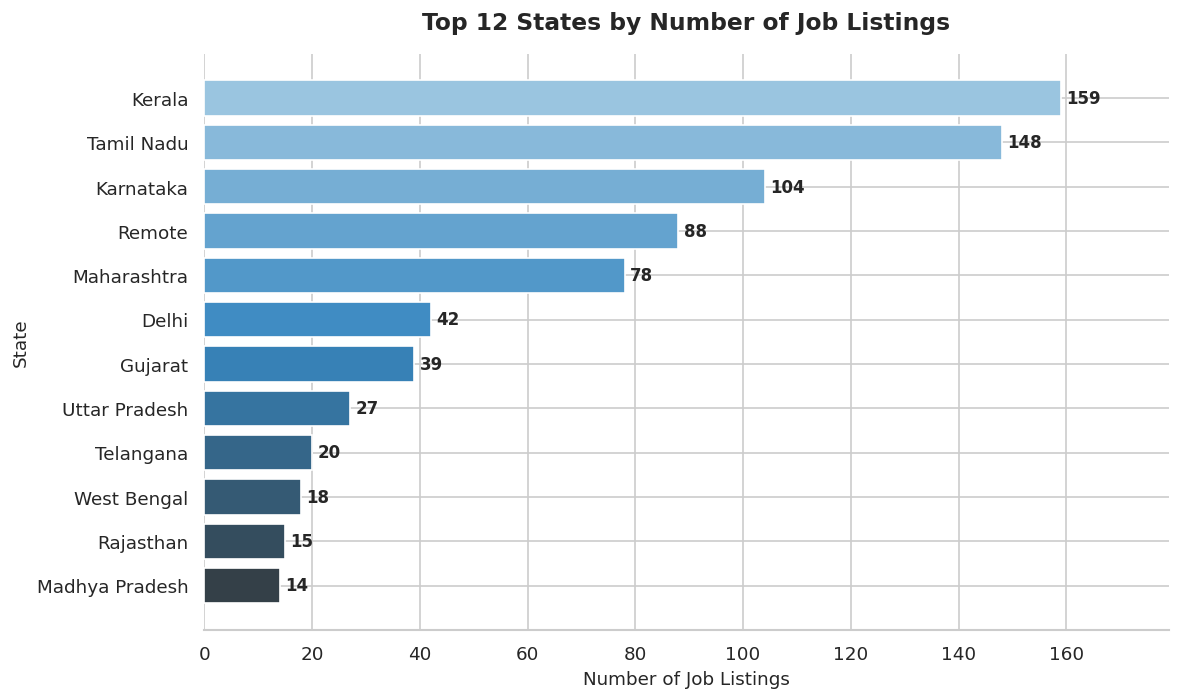


 Top state: Kerala with 159 listings


In [14]:
state_counts = df['State'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(state_counts.index[::-1], state_counts.values[::-1],
               color=sns.color_palette('Blues_d', len(state_counts))[::-1],
               edgecolor='white')

for bar, val in zip(bars, state_counts.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 12 States by Number of Job Listings', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Job Listings', fontsize=11)
ax.set_ylabel('State', fontsize=11)
ax.set_xlim(0, state_counts.values.max() + 20)
sns.despine(left=True)
plt.tight_layout()
plt.show()

print(f'\n Top state: {state_counts.index[0]} with {state_counts.values[0]} listings')

### — Job Category Distribution

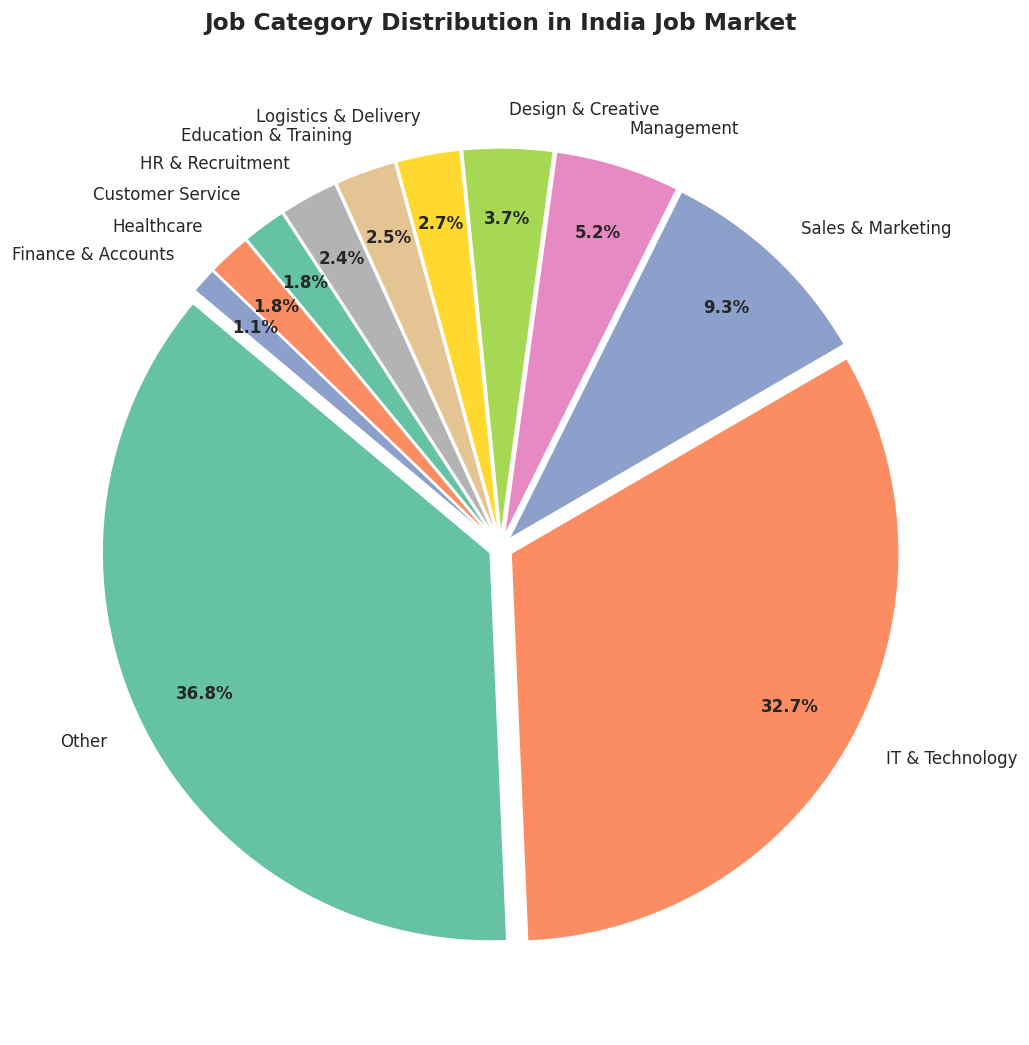

In [15]:
cat_counts = df['Job_Category'].value_counts()

colors = sns.color_palette('Set2', len(cat_counts))
explode = [0.03] * len(cat_counts)

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    pctdistance=0.82,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Job Category Distribution in India Job Market', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

###  — Remote vs On-site Jobs

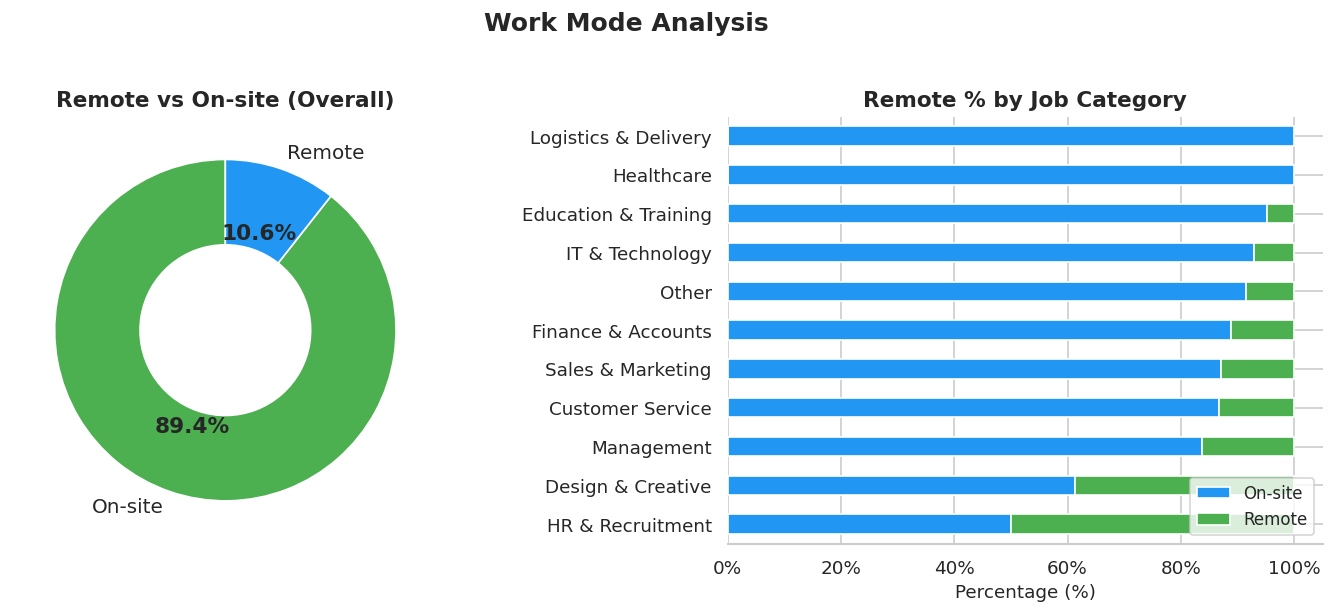

In [16]:
work_mode = df['Work_Mode'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart
colors_wm = ['#4CAF50', '#2196F3']
wedges, texts, autotexts = axes[0].pie(
    work_mode.values,
    labels=work_mode.index,
    autopct='%1.1f%%',
    colors=colors_wm,
    startangle=90,
    wedgeprops={'width': 0.5},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[0].set_title('Remote vs On-site (Overall)', fontsize=13, fontweight='bold')

# Remote vs on-site per category (stacked bar)
mode_by_cat = df.groupby(['Job_Category', 'Work_Mode']).size().unstack(fill_value=0)
mode_by_cat_pct = mode_by_cat.div(mode_by_cat.sum(axis=1), axis=0) * 100
mode_by_cat_pct = mode_by_cat_pct.sort_values('Remote', ascending=False)

mode_by_cat_pct.plot(kind='barh', stacked=True, ax=axes[1],
                      color=['#2196F3', '#4CAF50'], edgecolor='white')
axes[1].set_title('Remote % by Job Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Percentage (%)', fontsize=11)
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(loc='lower right', fontsize=10)
sns.despine(ax=axes[1], left=True)

plt.suptitle('Work Mode Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### — Salary Type Breakdown

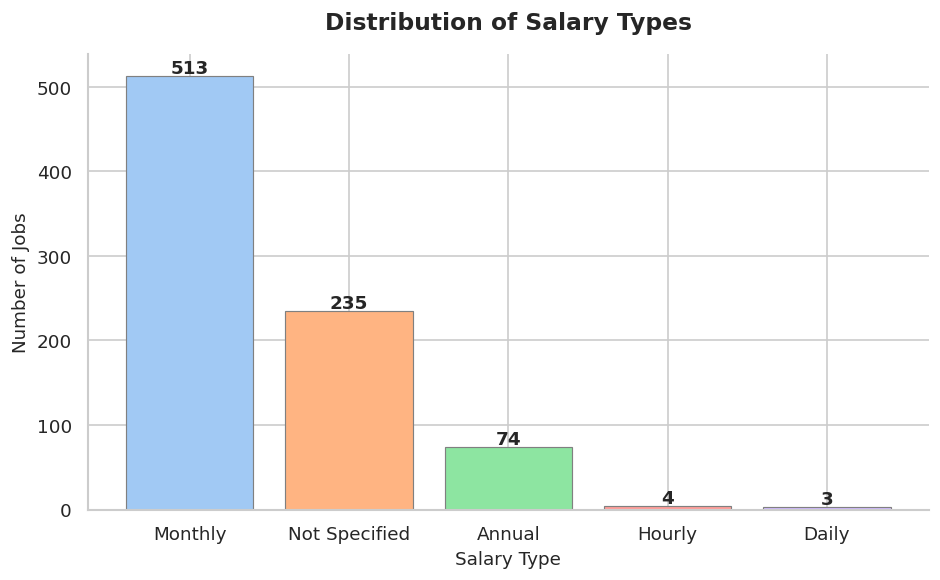


 235 jobs (28.3%) did not disclose salary — a common trend in Indian job postings.


In [17]:
sal_type = df['Salary_Type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sal_type.index, sal_type.values,
               color=sns.color_palette('pastel', len(sal_type)),
               edgecolor='grey', linewidth=0.7)

for bar, val in zip(bars, sal_type.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', fontsize=11, fontweight='bold')

ax.set_title('Distribution of Salary Types', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Salary Type', fontsize=11)
ax.set_ylabel('Number of Jobs', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

print(f'\n {sal_type["Not Specified"]} jobs ({sal_type["Not Specified"]/len(df)*100:.1f}%) did not disclose salary — a common trend in Indian job postings.')

### — Monthly Salary Distribution

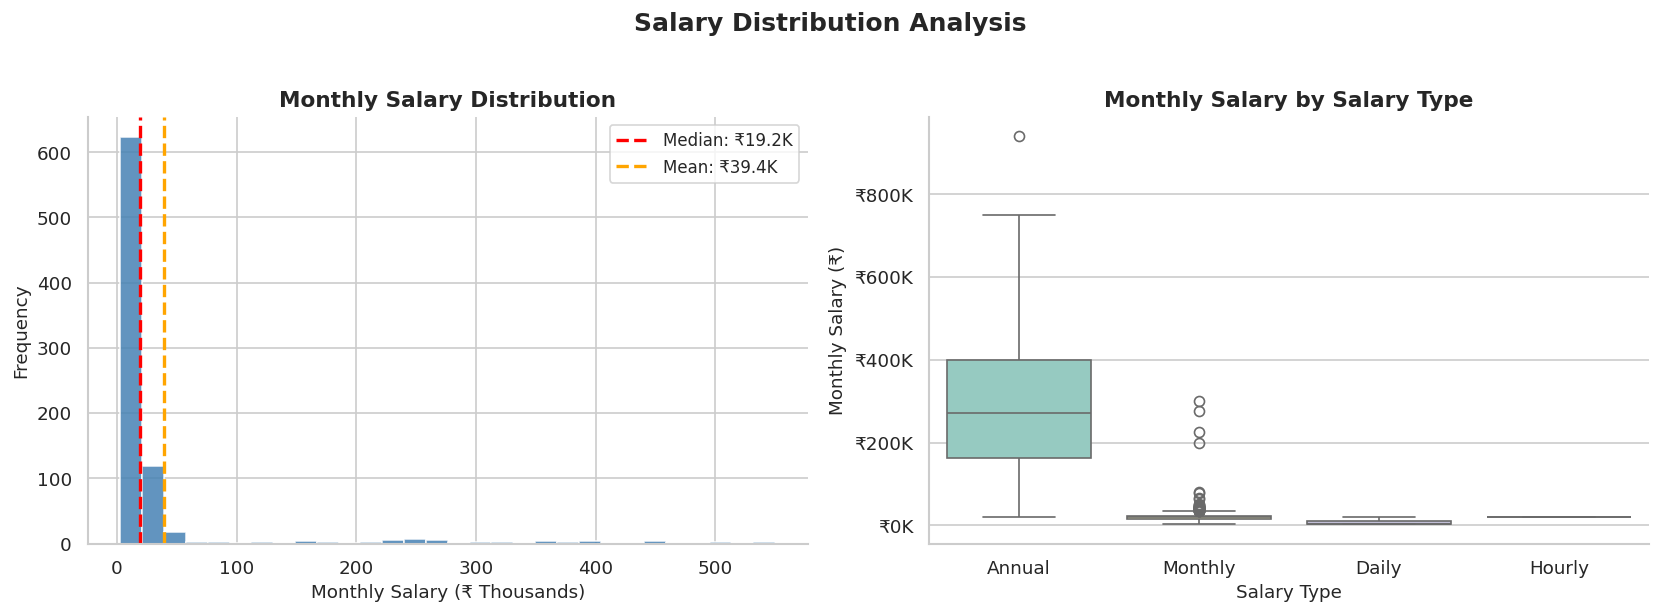


 Salary Statistics (Monthly, INR):
   Median : ₹19,250
   Mean   : ₹45,552
   Min    : ₹3,000
   Max    : ₹939,847


In [18]:
salary_data = df['Monthly_Salary_INR'].dropna()

# Cap at 99th percentile for readability
p99 = salary_data.quantile(0.99)
salary_capped = salary_data[salary_data <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(salary_capped / 1000, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(salary_capped.median()/1000, color='red', linestyle='--', linewidth=2,
                 label=f'Median: ₹{salary_capped.median()/1000:.1f}K')
axes[0].axvline(salary_capped.mean()/1000, color='orange', linestyle='--', linewidth=2,
                 label=f'Mean: ₹{salary_capped.mean()/1000:.1f}K')
axes[0].set_title('Monthly Salary Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Salary (₹ Thousands)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(fontsize=10)

# Box plot by Salary_Type
salary_by_type = df[df['Salary_Type'] != 'Not Specified'].copy()
# Convert annual to monthly for comparison
salary_by_type_monthly = salary_by_type[salary_by_type['Monthly_Salary_INR'].notna()]

sns.boxplot(data=salary_by_type_monthly, x='Salary_Type', y='Monthly_Salary_INR',
             ax=axes[1], palette='Set3')
axes[1].set_title('Monthly Salary by Salary Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Salary Type', fontsize=11)
axes[1].set_ylabel('Monthly Salary (₹)', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

sns.despine()
plt.suptitle('Salary Distribution Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n Salary Statistics (Monthly, INR):')
print(f'   Median : ₹{salary_data.median():,.0f}')
print(f'   Mean   : ₹{salary_data.mean():,.0f}')
print(f'   Min    : ₹{salary_data.min():,.0f}')
print(f'   Max    : ₹{salary_data.max():,.0f}')

### — Average Monthly Salary by Job Category

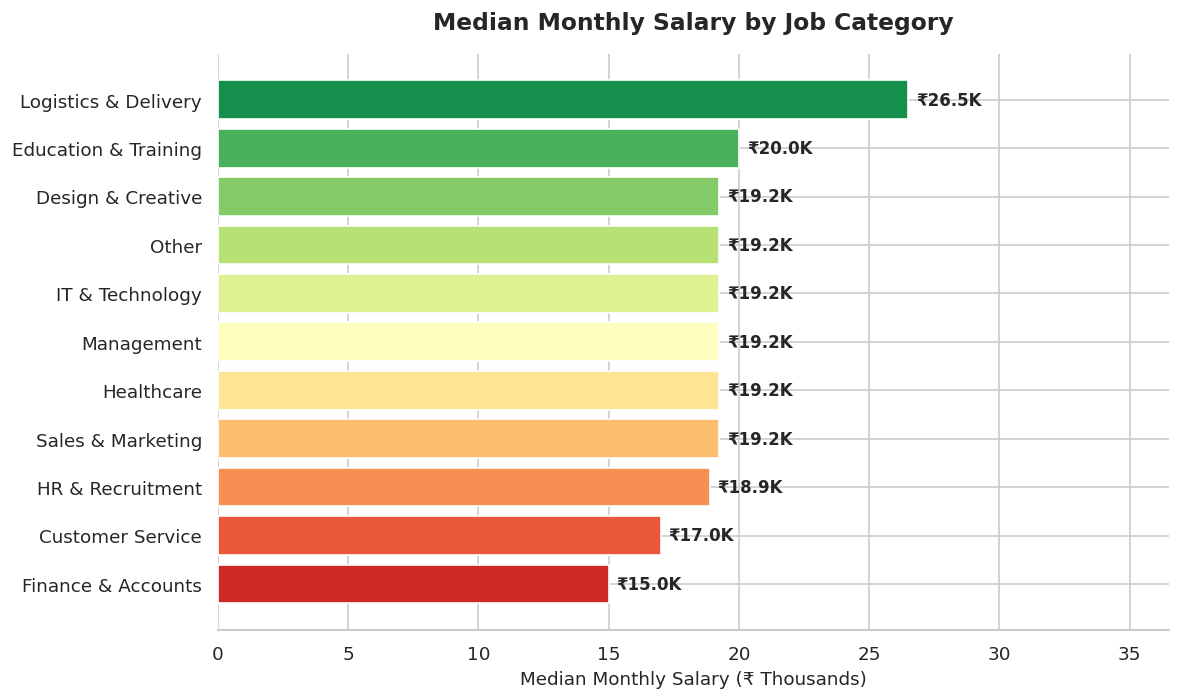

In [19]:
avg_sal = (df.groupby('Job_Category')['Monthly_Salary_INR']
             .median()
             .dropna()
             .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('RdYlGn', len(avg_sal))

bars = ax.barh(avg_sal.index[::-1], avg_sal.values[::-1] / 1000,
               color=palette, edgecolor='white')

for bar, val in zip(bars, avg_sal.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'₹{val/1000:.1f}K', va='center', fontsize=10, fontweight='bold')

ax.set_title('Median Monthly Salary by Job Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Median Monthly Salary (₹ Thousands)', fontsize=11)
ax.set_xlim(0, avg_sal.values.max()/1000 + 10)
sns.despine(left=True)
plt.tight_layout()
plt.show()

### — Top 10 Cities by Job Listings

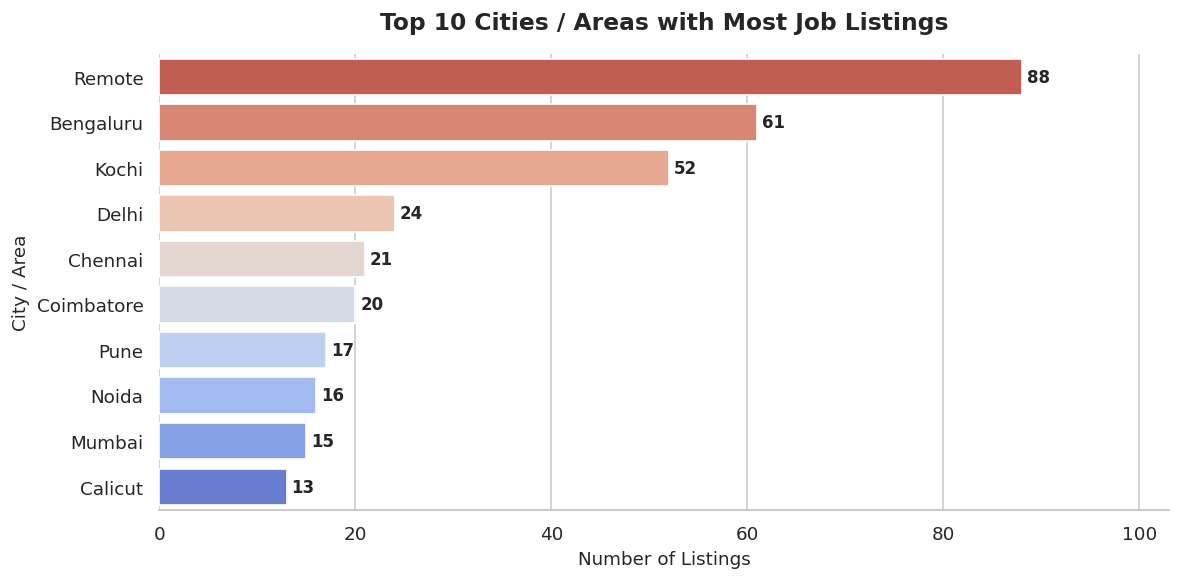

In [20]:
city_counts = df['Locality'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=city_counts.values, y=city_counts.index,
             palette='coolwarm_r', ax=ax)

for i, val in enumerate(city_counts.values):
    ax.text(val + 0.5, i, str(val), va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Cities / Areas with Most Job Listings', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Listings', fontsize=11)
ax.set_ylabel('City / Area', fontsize=11)
ax.set_xlim(0, city_counts.values.max() + 15)
sns.despine(left=True)
plt.tight_layout()
plt.show()

### — Heatmap: Job Category vs State

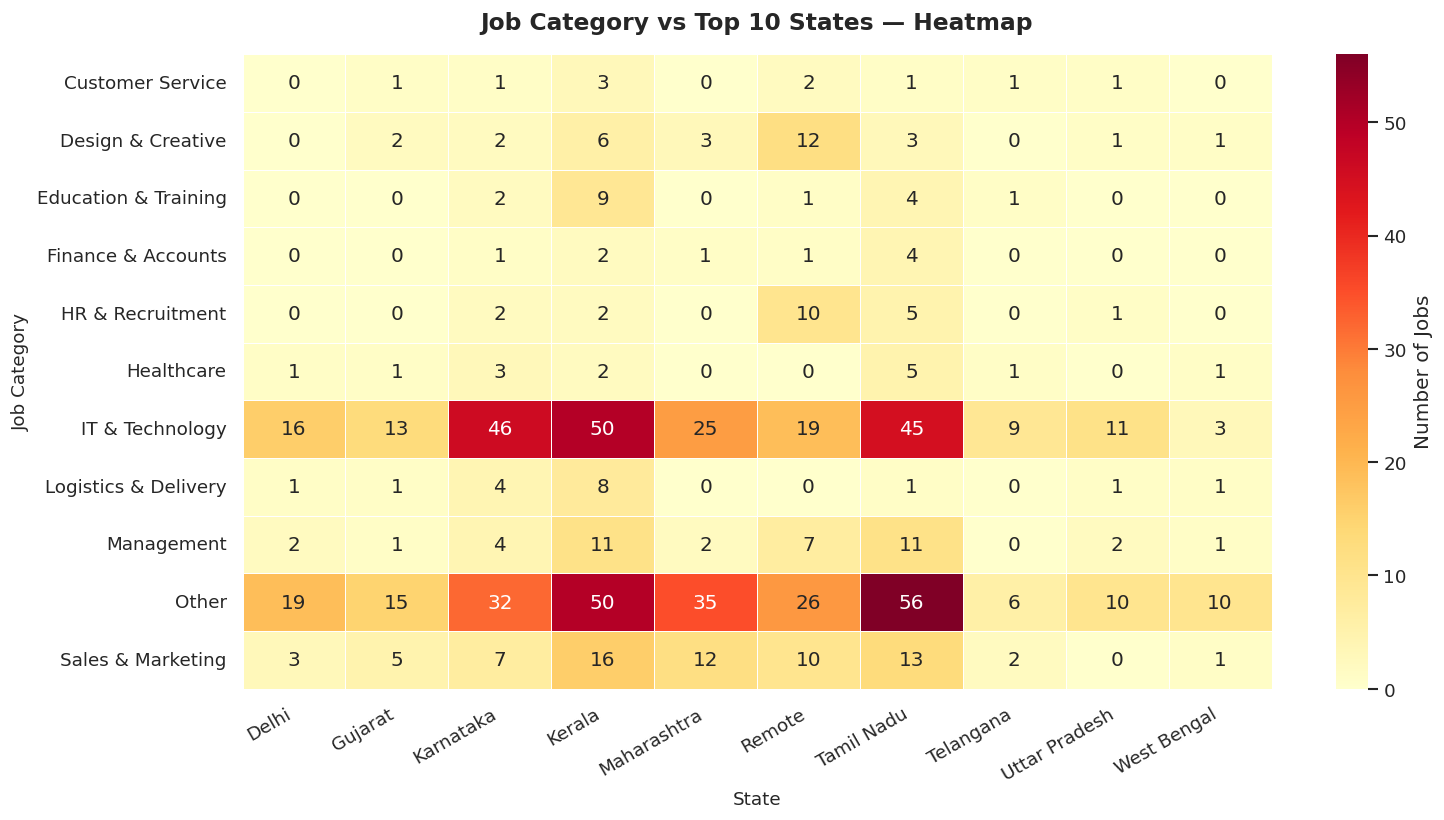


 Kerala and Tamil Nadu dominate listings; IT & Technology jobs are concentrated in Karnataka (Bengaluru).


In [21]:
top_states = df['State'].value_counts().head(10).index
heat_data = (df[df['State'].isin(top_states)]
               .groupby(['Job_Category', 'State'])
               .size()
               .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heat_data, annot=True, fmt='d', cmap='YlOrRd',
             linewidths=0.5, linecolor='white', ax=ax,
             cbar_kws={'label': 'Number of Jobs'})

ax.set_title('Job Category vs Top 10 States — Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Job Category', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n Kerala and Tamil Nadu dominate listings; IT & Technology jobs are concentrated in Karnataka (Bengaluru).')

### — Average Salary by State (Top 10 States)

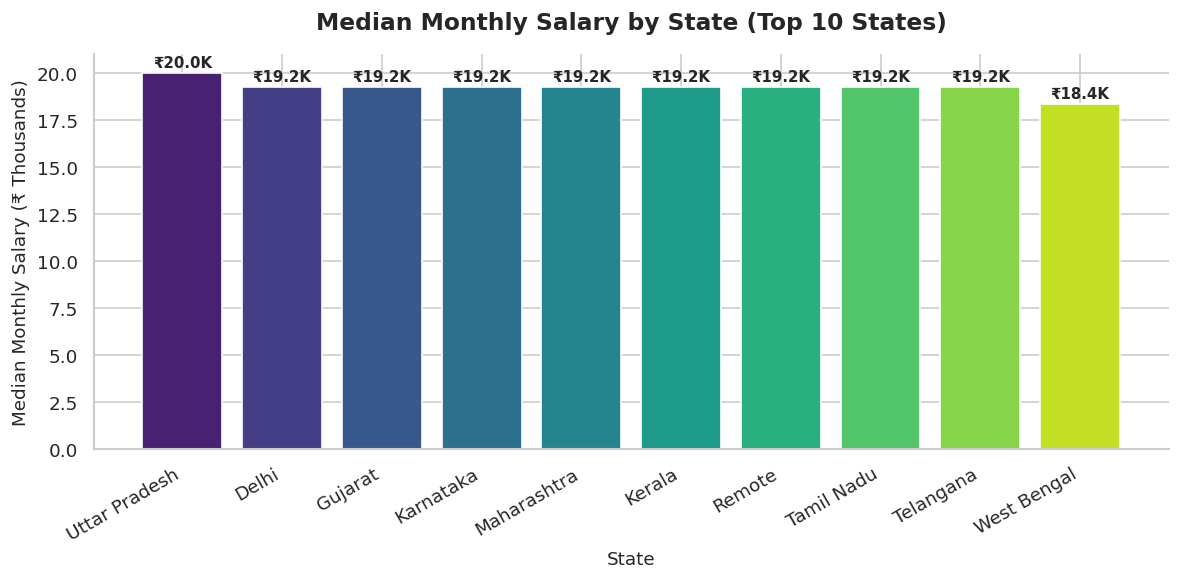

In [22]:
state_salary = (df[df['State'].isin(top_states)]
                  .groupby('State')['Monthly_Salary_INR']
                  .median()
                  .dropna()
                  .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(state_salary.index, state_salary.values / 1000,
               color=sns.color_palette('viridis', len(state_salary)),
               edgecolor='white')

for bar, val in zip(bars, state_salary.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'₹{val/1000:.1f}K', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Median Monthly Salary by State (Top 10 States)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Median Monthly Salary (₹ Thousands)', fontsize=11)
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

### — Top 15 Most In-Demand Job Titles

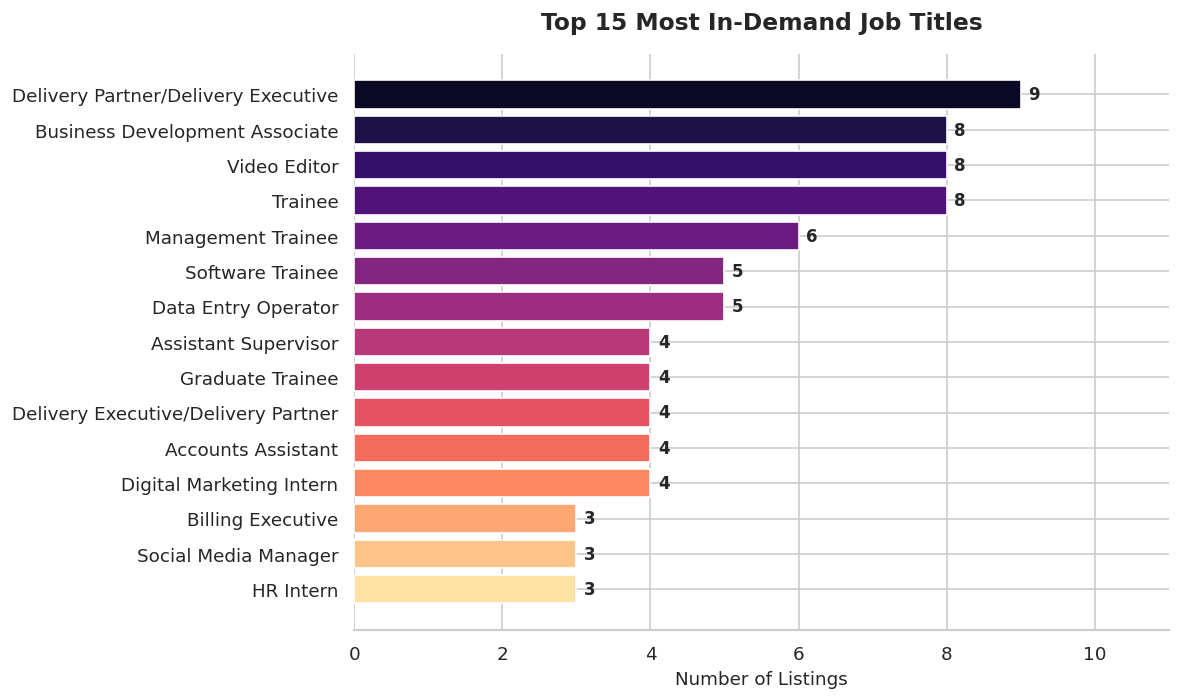

In [23]:
top_jobs = df['Job_Title'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_jobs.index[::-1], top_jobs.values[::-1],
               color=sns.color_palette('magma', 15)[::-1],
               edgecolor='white')

for bar, val in zip(bars, top_jobs.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 15 Most In-Demand Job Titles', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Listings', fontsize=11)
ax.set_xlim(0, top_jobs.values.max() + 2)
sns.despine(left=True)
plt.tight_layout()
plt.show()

---
##  5. Key Insights & Conclusions

After analyzing 829 job listings from India's job market, here are the **key takeaways**:

---

###  Top Insights

| # | Insight |
|---|---|
| 1 | **Kerala leads** in job listings, followed closely by Tamil Nadu and Karnataka |
| 2 | **IT & Technology** is the largest job category, driven by Bengaluru's booming tech ecosystem |
| 3 | **~28% of jobs are remote** — a significant post-pandemic shift in India's work culture |
| 4 | The **median monthly salary** is around ₹19,000–₹20,000, reflecting mid-level entry roles |
| 5 | **IT & Tech roles** command the highest salaries, followed by Finance and Management |
| 6 | Nearly **28% of postings** did not disclose salary — a common Indian hiring practice |
| 7 | **Delivery & Logistics** jobs are in high demand (Swiggy/Zomato era effect) |
| 8 | **Education & Training** roles are widespread across smaller towns and cities |

---

###  What I Would Explore Next
- **Skills-based analysis** — if skills/requirements data were available
- **Time-series trends** — if posting dates were available
- **NLP on Job Titles** — to better auto-classify roles
- **Salary prediction model** — using state, category, and work mode as features

---

*Thank you for reading! This project demonstrates end-to-end data analysis — from raw messy data to clean insights. Feel free to fork and build on it! 